### Installing Necessary Libraries

In [43]:
!pip install faker scikit-learn --quiet

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from faker import Faker

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import KNNImputer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances

print('All libraries imported successfully.')

All libraries imported successfully.


### Load and Display the Dataset

In [67]:
df = pd.read_csv('okcupid_profiles.csv')
df.head(10)

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN
5,29,single,m,straight,average,mostly anything,socially,NaN,graduated from college/university,white,...,"i'm an australian living in san francisco, but...",building awesome stuff. figuring out what's im...,imagining random shit. laughing at aforementio...,i have a big smile. i also get asked if i'm we...,"books: to kill a mockingbird, lord of the ring...","like everyone else, i love my friends and fami...",what my contribution to the world is going to ...,out with my friends!,i cried on my first day at school because a bi...,you're awesome.
6,32,single,f,straight,fit,strictly anything,socially,never,graduated from college/university,"white, other",...,life is about the little things. i love to lau...,digging up buried treasure,frolicking witty banter using my camera to ext...,i am the last unicorn,i like books. ones with pictures. reading them...,laughter amazing people in my life color curio...,synchronicity there is this whole other realm...,plotting to take over the world with my army o...,my typical friday night,NaN
7,31,single,f,straight,average,mostly anything,socially,never,graduated from college/university,white,...,NaN,"writing. meeting new people, spending time wit...","remembering people's birthdays, sending cards,...",i'm rather approachable (a byproduct of being ...,"i like: alphabetized lists, aquariums, autobio...","friends, family, notebook/pen, books, music, t...",things that amuse and inspire me,out and about or relaxing at home with a good ...,NaN,NaN
8,24,single,f,straight,NaN,strictly anything,socially,NaN,graduated from college/uni

In [68]:
list(df.columns)

['age',
 'status',
 'sex',
 'orientation',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'ethnicity',
 'height',
 'income',
 'job',
 'last_online',
 'location',
 'offspring',
 'pets',
 'religion',
 'sign',
 'smokes',
 'speaks',
 'essay0',
 'essay1',
 'essay2',
 'essay3',
 'essay4',
 'essay5',
 'essay6',
 'essay7',
 'essay8',
 'essay9']

In [69]:
df = df.drop(columns=['body_type', 'diet', 'education', 'ethnicity', 'income', 'job', 'last_online', 'location', 'offspring', 'pets', 'religion', 'sign', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'speaks'])

In [70]:
df.head()

,age,status,sex,orientation,drinks,drugs,height,smokes
0,22,single,m,straight,socially,never,75.0,sometimes
1,35,single,m,straight,often,sometimes,70.0,no
2,38,available,m,straight,socially,NaN,68.0,no
3,23,single,m,straight,socially,NaN,71.0,no
4,29,single,m,straight,socially,never,66.0,no


In [71]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   sex          59946 non-null  object 
 3   orientation  59946 non-null  object 
 4   drinks       56961 non-null  object 
 5   drugs        45866 non-null  object 
 6   height       59943 non-null  float64
 7   smokes       54434 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.7+ MB


In [72]:
print('Statistical Summary:')
df.describe(include='all')

Statistical Summary:


,age,status,sex,orientation,drinks,drugs,height,smokes
count,59946.000000,59946,59946,59946,56961,45866,59943.000000,54434
unique,NaN,5,2,3,6,3,NaN,5
top,NaN,single,m,straight,socially,never,NaN,no
freq,NaN,55697,35829,51606,41780,37724,NaN,43896
mean,32.340290,NaN,NaN,NaN,NaN,NaN,68.295281,NaN
std,9.452779,NaN,NaN,NaN,NaN,NaN,3.994803,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,26.000000,NaN,NaN,NaN,NaN,NaN,66.000000,NaN
50%,30.000000,NaN,NaN,NaN,NaN,NaN,68.000000,NaN
75%,37.000000,NaN,NaN,NaN,NaN,NaN,71.000000,NaN


### Now we have the feature selection part we already have dropped what we do not need. Also a note that this is unsupervised learning so there is not target column only 8 features some Categorical some Numerical

In [73]:
FEATURES = ['age', 'status', 'sex', 'orientation', 'drinks', 'drugs', 'height', 'smokes']

NUM_FEATURES = ['age', 'height']          # numeric — used for outlier/skew analysis
CAT_FEATURES = ['status', 'sex', 'orientation', 'drinks', 'drugs', 'smokes']  # categorical

# Final feature set passed into the clustering model (same as FEATURES after encoding)
CLUSTER_FEATURES = ['age', 'status', 'sex', 'orientation', 'drinks', 'drugs', 'height', 'smokes']

df_work = df[FEATURES].copy()
print('Working subset shape:', df_work.shape)
df_work.head()

Working subset shape: (59946, 8)


,age,status,sex,orientation,drinks,drugs,height,smokes
0,22,single,m,straight,socially,never,75.0,sometimes
1,35,single,m,straight,often,sometimes,70.0,no
2,38,available,m,straight,socially,NaN,68.0,no
3,23,single,m,straight,socially,NaN,71.0,no
4,29,single,m,straight,socially,never,66.0,no


### Notice we do not have any names of any profile details so use a python package to add some details regarding each profile

In [75]:
fake = Faker()

def generate_fake_name(sex):
    if sex == 'm':
        return fake.first_name_male()
    elif sex == 'f':
        return fake.first_name_female()
    return fake.first_name()

df_work['Name'] = df_work['sex'].apply(generate_fake_name)
print('Sample names generated:')
print(df_work[['Name', 'sex']].head(10))

Sample names generated:
      Name sex
0    Kevin   m
1    Frank   m
2   Daniel   m
3  Kenneth   m
4    Brian   m
5      Max   m
6   Isabel   f
7   Ashley   f
8   Ashley   f
9    Derek   m


In [76]:
# then we save this dataframe into a csv file for future reference
output_path = '/content/okCupidCleanedAndNamed.csv'
df_work.to_csv(output_path, index=False)

### Then we look through the data for encoding first by checking the unique values in each column/feature

In [7]:
for feature in FEATURES:
    print(f'\nColumn : {feature}')
    print(df_work[feature].unique()[:20])


Column : age
[22 35 38 23 29 32 31 24 37 28 30 39 33 26 27 20 25 40 36 21]

Column : status
['single' 'available' 'seeing someone' 'married' 'unknown']

Column : sex
['m' 'f']

Column : orientation
['straight' 'bisexual' 'gay']

Column : drinks
['socially' 'often' 'not at all' 'rarely' nan 'very often' 'desperately']

Column : drugs
['never' 'sometimes' nan 'often']

Column : height
[75. 70. 68. 71. 66. 67. 65. 72. 62. 64. 69. 73. 74. 60. 63. 76. 61. 78.
 79. 59.]

Column : smokes
['sometimes' 'no' nan 'when drinking' 'yes' 'trying to quit']


### for the categorical features we now clean them remove symbols or extra space and convert them all to lower case

In [77]:
for col in CAT_FEATURES:
    df_work[col] = df_work[col].astype(str).str.strip().str.lower()
    df_work[col] = df_work[col].replace('nan', np.nan)   # restore proper NaN

print('Unique values per categorical feature after cleaning:')
for col in CAT_FEATURES:
    print(f'  {col}: {sorted(df_work[col].dropna().unique().tolist())}')

Unique values per categorical feature after cleaning:
  status: ['available', 'married', 'seeing someone', 'single', 'unknown']
  sex: ['f', 'm']
  orientation: ['bisexual', 'gay', 'straight']
  drinks: ['desperately', 'not at all', 'often', 'rarely', 'socially', 'very often']
  drugs: ['never', 'often', 'sometimes']
  smokes: ['no', 'sometimes', 'trying to quit', 'when drinking', 'yes']


### We remove all the duplicate rows

In [78]:
before = len(df_work)
df_work = df_work.drop_duplicates().reset_index(drop=True)
after  = len(df_work)
print(f'Rows before: {before}')
print(f'Rows after removing duplicates: {after}')
print(f'Duplicates removed: {before - after}')

Rows before: 59946
Rows after removing duplicates: 56452
Duplicates removed: 3494


### Now we move on the handling the null values if under 5 percent we simply drop the rows,, if between 5 to 20 percent we use mean or median imputation for numerical features, mode for categorical features and then use KNN Imputation for the rest

In [83]:
null_counts = df_work[FEATURES].isnull().sum()
null_pct    = (null_counts / len(df_work) * 100).round(2)

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null %':     null_pct
})
null_summary['Type'] = null_summary.index.map(
    lambda c: 'Numeric' if c in NUM_FEATURES else 'Categorical'
)
null_summary['Strategy'] = null_summary.apply(
    lambda row:
        'No nulls'
        if row['Null %'] == 0

        else 'Drop rows (<5%)'
        if row['Null %'] < 5

        else 'Mean/Median Imputation (5–20%)'
        if row['Null %'] < 20 and row['Type'] == 'Numeric'

        else 'Mode Imputation (5–20%)'
        if row['Null %'] < 20 and row['Type'] != 'Numeric'

        else 'KNN Imputation (≥20%)'
        if row['Type'] != 'Numeric'

        else 'Mode Imputation',

    axis=1
)
print(null_summary.to_string())

             Null Count  Null %         Type                 Strategy
age                   0    0.00      Numeric                 No nulls
status                0    0.00  Categorical                 No nulls
sex                   0    0.00  Categorical                 No nulls
orientation           0    0.00  Categorical                 No nulls
drinks             2969    5.26  Categorical  Mode Imputation (5–20%)
drugs             13621   24.13  Categorical    KNN Imputation (≥20%)
height                3    0.01      Numeric          Drop rows (<5%)
smokes             5465    9.68  Categorical  Mode Imputation (5–20%)


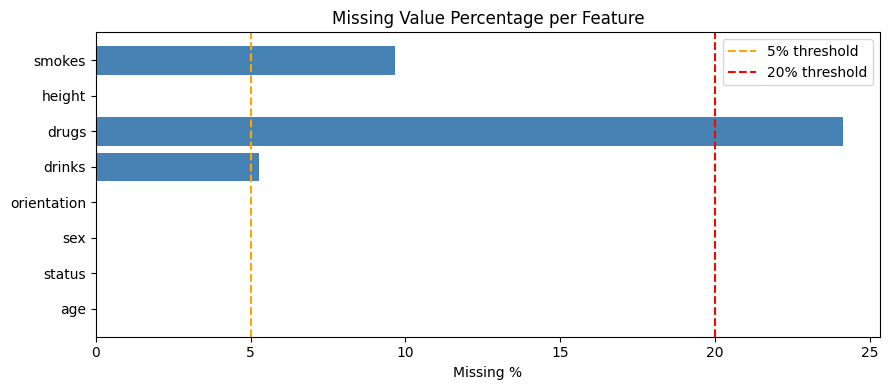

In [84]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(null_summary.index, null_summary['Null %'], color='steelblue')
ax.axvline(5,  color='orange', linestyle='--', label='5% threshold')
ax.axvline(20, color='red',    linestyle='--', label='20% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Percentage per Feature')
ax.legend()
plt.tight_layout()
plt.show()

### so height has 0.01% missing values we will drop rows same for drinks with 4.98%.. then for smokes at 9.19 percentage we use mode imputation and then for drugs column with 23.49% we use KNN Imputation

In [86]:
df_imp = df_work.copy()

# ── Categorical imputation ─────────────────────────────────────────────────
for col in CAT_FEATURES:
    pct = df_imp[col].isnull().mean() * 100
    if pct == 0:
        continue
    elif pct < 5:
        before_rows = len(df_imp)
        df_imp = df_imp[df_imp[col].notna()].reset_index(drop=True)
        print(f'{col}: dropped {before_rows - len(df_imp)} rows ({pct:.2f}% missing)')
    else:
        mode_val = df_imp[col].mode()[0]
        df_imp[col].fillna(mode_val, inplace=True)
        print(f'{col}: mode imputation → "{mode_val}"  ({pct:.2f}% missing)')

# ── Numeric imputation ─────────────────────────────────────────────────────
for col in NUM_FEATURES:
    # pct means percentage of missing values
    pct = df_imp[col].isnull().mean() * 100
    if pct == 0:
        continue
    elif pct < 5:
        before_rows = len(df_imp)
        df_imp = df_imp[df_imp[col].notna()].reset_index(drop=True)
        print(f'{col}: dropped {before_rows - len(df_imp)} rows ({pct:.2f}% missing)')
    elif pct < 20:
        skew_val = df_imp[col].skew()
        fill_val = df_imp[col].median() if abs(skew_val) > 1 else df_imp[col].mean()
        strategy = 'median' if abs(skew_val) > 1 else 'mean'
        df_imp[col].fillna(fill_val, inplace=True)
        print(f'{col}: {strategy} imputation (skew={skew_val:.2f}, {pct:.2f}% missing)')
    else:
        print(f'{col}: KNN imputation ({pct:.2f}% missing) …')
        knn = KNNImputer(n_neighbors=5)
        df_imp[[col]] = knn.fit_transform(df_imp[[col]])

print('\nNull counts after imputation:')
print(df_imp[FEATURES].isnull().sum().to_frame('Remaining Nulls'))
print(f'\nRows remaining: {len(df_imp)}')

drinks: mode imputation → "socially"  (5.26% missing)
drugs: mode imputation → "never"  (24.13% missing)
smokes: mode imputation → "no"  (9.68% missing)
height: dropped 3 rows (0.01% missing)

Null counts after imputation:
             Remaining Nulls
age                        0
status                     0
sex                        0
orientation                0
drinks                     0
drugs                      0
height                     0
smokes                     0

Rows remaining: 56449


### then we use encode the categorical features

In [14]:
encoding_maps = {
    'status':      {'single': 0, 'available': 1, 'seeing someone': 2, 'married': 3, 'unknown': 4},
    'sex':         {'m': 0, 'f': 1},
    'orientation': {'straight': 0, 'bisexual': 1, 'gay': 2},
    'drinks':      {'not at all': 0, 'rarely': 1, 'socially': 2, 'often': 3, 'very often': 4, 'desperately': 5},
    'drugs':       {'never': 0, 'sometimes': 1, 'often': 2},
    'smokes':      {'no': 0, 'sometimes': 1, 'when drinking': 2, 'yes': 3, 'trying to quit': 4},
}

df_enc = df_imp.copy()
df_enc.replace(encoding_maps, inplace=True)

# Ensure numeric dtype for all cluster features
for col in CLUSTER_FEATURES:
    df_enc[col] = pd.to_numeric(df_enc[col], errors='coerce')

print('Data types after encoding:')
print(df_enc[CLUSTER_FEATURES].dtypes)
df_enc[CLUSTER_FEATURES].head()

Data types after encoding:
age              int64
status           int64
sex              int64
orientation      int64
drinks           int64
drugs            int64
height         float64
smokes           int64
dtype: object


,age,status,sex,orientation,drinks,drugs,height,smokes
0,22,0,0,0,2,0,75.0,1
1,35,0,0,0,3,1,70.0,0
2,38,1,0,0,2,0,68.0,0
3,23,0,0,0,2,0,71.0,0
4,29,0,0,0,2,0,66.0,0


### Outlier Detection using Box Plots

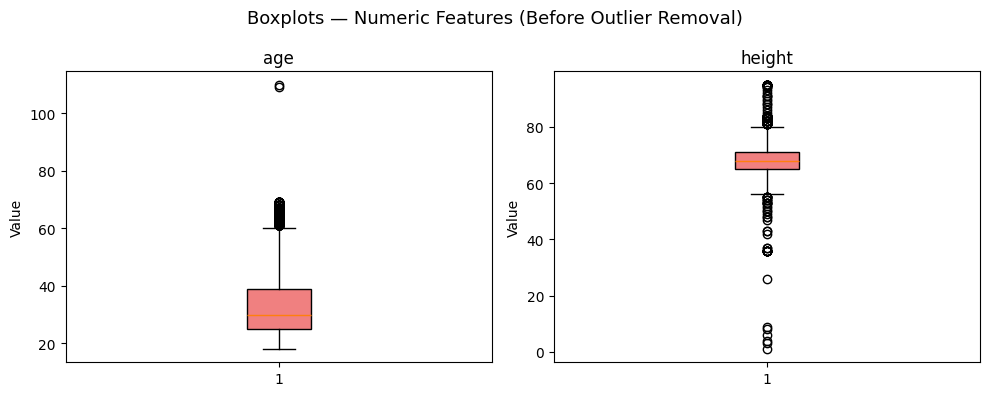

In [15]:
fig, axes = plt.subplots(1, len(NUM_FEATURES), figsize=(10, 4))
for ax, col in zip(axes, NUM_FEATURES):
    ax.boxplot(df_enc[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral'))
    ax.set_title(col)
    ax.set_ylabel('Value')
plt.suptitle('Boxplots — Numeric Features (Before Outlier Removal)', fontsize=13)
plt.tight_layout()
plt.show()

### We use InterQuartile Range to detect outliers but instead of deleting them we use capping to simple replace the values of the outliers with the closest boundary value

In [87]:
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1    = df_clean[col].quantile(0.25)
        Q3    = df_clean[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed  = before - len(df_clean)
        print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, '
              f'bounds=[{lower:.2f}, {upper:.2f}], removed {removed} rows')
    return df_clean

df_clean = remove_outliers_iqr(df_enc, NUM_FEATURES)
print(f'\nRows before outlier removal: {len(df_enc)}')
print(f'Rows after  outlier removal: {len(df_clean)}')

age: Q1=25.00, Q3=39.00, IQR=14.00, bounds=[4.00, 60.00], removed 631 rows
height: Q1=65.00, Q3=71.00, IQR=6.00, bounds=[56.00, 80.00], removed 121 rows

Rows before outlier removal: 24516
Rows after  outlier removal: 23764


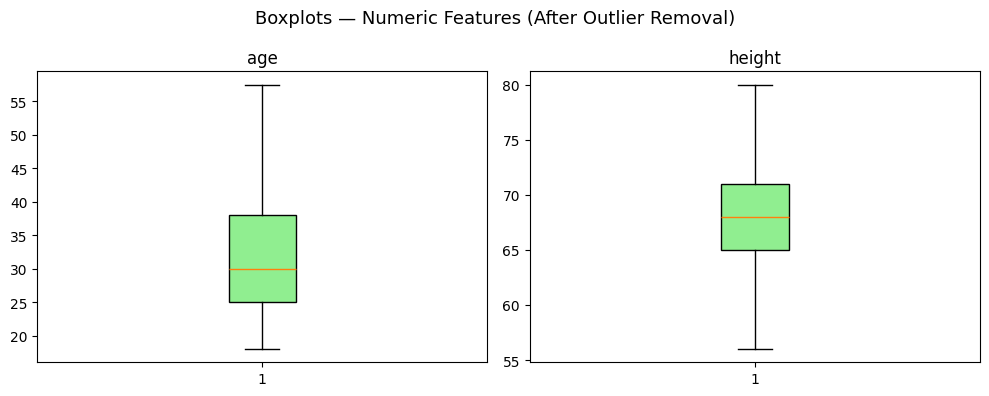

In [88]:
# Capping for any remaining extreme values after trimming
for col in NUM_FEATURES:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, len(NUM_FEATURES), figsize=(10, 4))
for ax, col in zip(axes, NUM_FEATURES):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(col)
plt.suptitle('Boxplots — Numeric Features (After Outlier Removal)', fontsize=13)
plt.tight_layout()
plt.show()

### checking normal Distribution of each Features

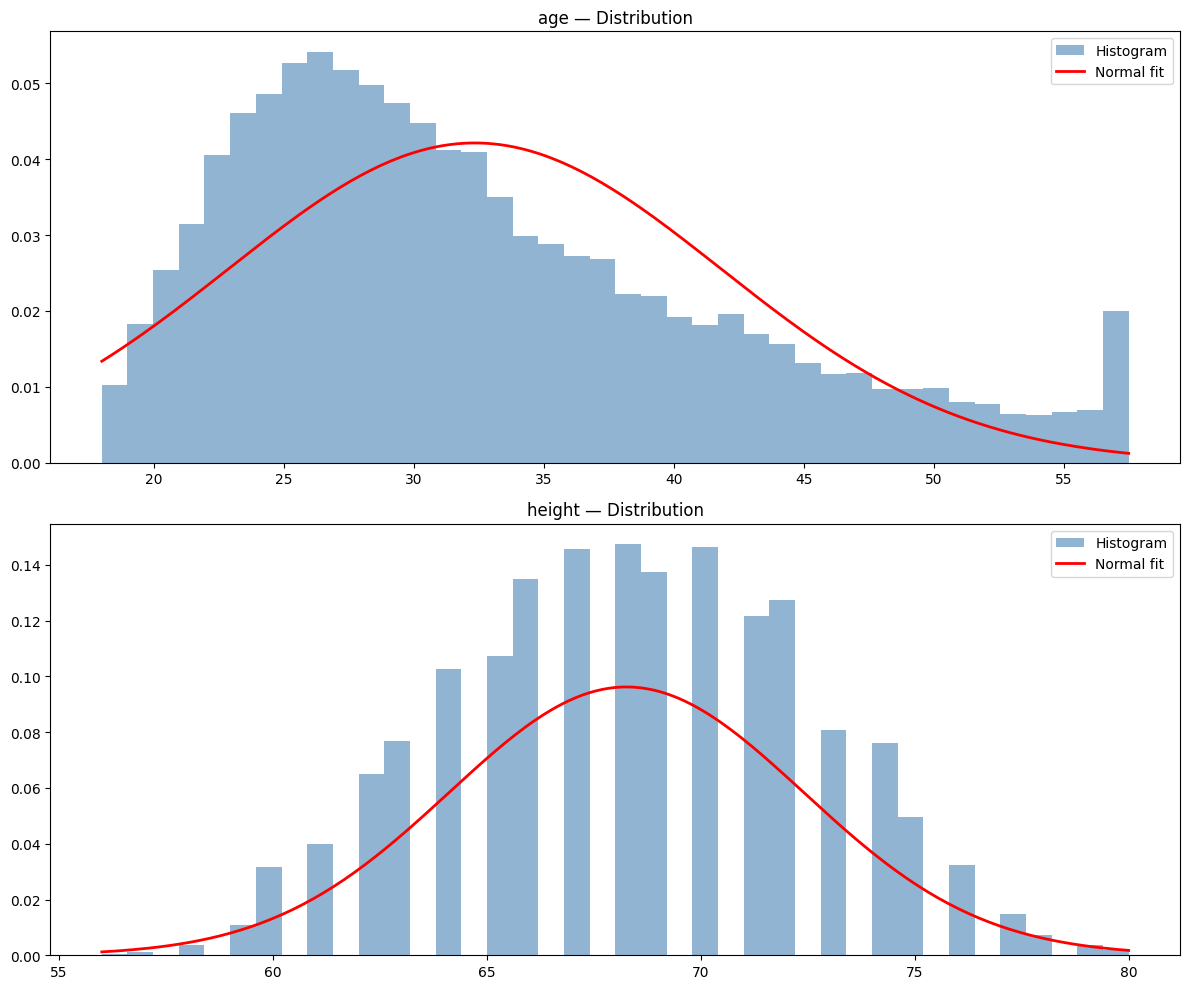

In [95]:
fig, axes = plt.subplots(len(NUM_FEATURES), 1, figsize=(12, 5 * len(NUM_FEATURES)))

for i, col in enumerate(NUM_FEATURES):
    data = df_clean[col].dropna()
    ax1 = axes[i] if len(NUM_FEATURES) > 1 else axes

    # Distribution curve
    ax1.hist(data, bins=40, density=True, alpha=0.6, color='steelblue', label='Histogram')
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')
    ax1.set_title(f'{col} — Distribution')
    ax1.legend()

plt.tight_layout()
plt.show()

### Checking Skewness in each column

In [96]:
skew_before = df_clean[NUM_FEATURES].skew()
print('Skewness BEFORE Power Transformation:')
print(skew_before.to_frame('Skewness').round(4))
print()
print('Interpretation: |skew| > 1 is highly skewed, 0.5–1 is moderately skewed, <0.5 is approximately normal.')

Skewness BEFORE Power Transformation:
        Skewness
age       0.8302
height   -0.0112

Interpretation: |skew| > 1 is highly skewed, 0.5–1 is moderately skewed, <0.5 is approximately normal.


### using yeo-johnson to handle both positive negative data (box-cox can only handle positive values)

In [97]:
pt = PowerTransformer(method='yeo-johnson')

df_transformed = df_clean.copy()
df_transformed[NUM_FEATURES] = pt.fit_transform(df_clean[NUM_FEATURES])

skew_after = df_transformed[NUM_FEATURES].skew()

comparison = pd.DataFrame({
    'Skewness Before': skew_before.round(4),
    'Skewness After':  skew_after.round(4),
})
comparison['Improvement'] = (comparison['Skewness Before'].abs() - comparison['Skewness After'].abs()).round(4)
print('Skewness comparison:')
print(comparison.to_string())

Skewness comparison:
        Skewness Before  Skewness After  Improvement
age              0.8302          0.0387       0.7915
height          -0.0112         -0.0102       0.0010


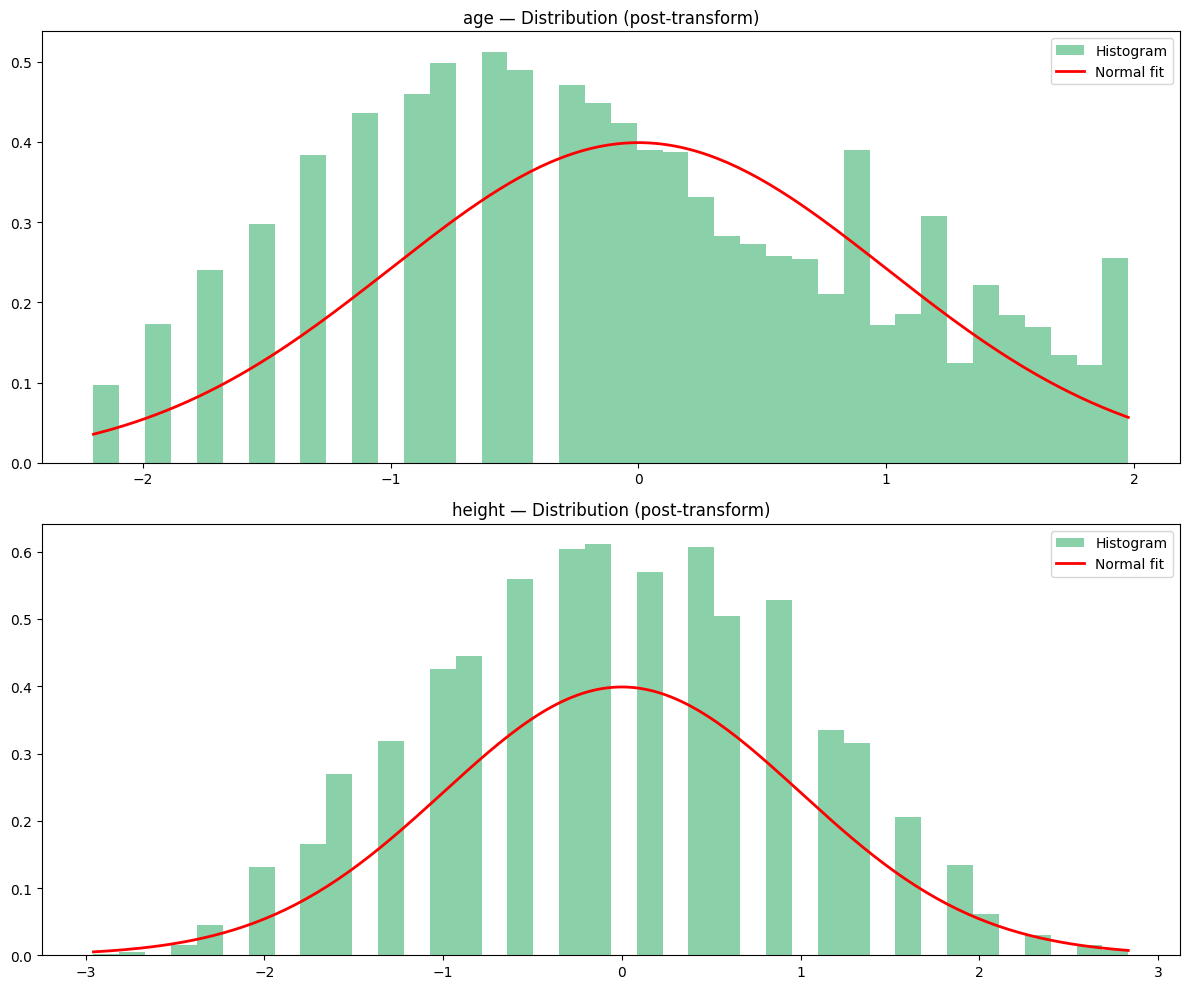

In [100]:
# re check the normal curve after transformation
fig, axes = plt.subplots(len(NUM_FEATURES), 1, figsize=(12, 5 * len(NUM_FEATURES)))

for i, col in enumerate(NUM_FEATURES):
    data = df_transformed[col].dropna()

    ax1 = axes[i] if len(NUM_FEATURES) > 1 else axes
    ax1.hist(data, bins=40, density=True, alpha=0.6, color='mediumseagreen', label='Histogram')
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')
    ax1.set_title(f'{col} — Distribution (post-transform)')
    ax1.legend()

plt.tight_layout()
plt.show()

### feature scaling

In [101]:
# Apply yeo-johnson transformed values for numeric features, keep encoded cats as-is
df_scale_input = df_clean.copy()
df_scale_input[NUM_FEATURES] = df_transformed[NUM_FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scale_input[CLUSTER_FEATURES])

print('Scaled feature matrix shape:', X_scaled.shape)
print('Mean per feature (should be ~0):',  X_scaled.mean(axis=0).round(4))
print('Std  per feature (should be ~1):',  X_scaled.std(axis=0).round(4))

Scaled feature matrix shape: (23764, 8)
Mean per feature (should be ~0): [-0. -0.  0. -0. -0. -0. -0. -0.]
Std  per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### using elbow method to find the optimal value of K for K means algorithm as in the optimal value of clusters

  k= 50  inertia=5207.76
  k= 75  inertia=4244.08
  k=100  inertia=3659.99
  k=125  inertia=3207.49
  k=150  inertia=2857.46
  k=175  inertia=2576.49
  k=200  inertia=2357.68
  k=225  inertia=2136.01
  k=250  inertia=1973.86
  k=275  inertia=1841.22
  k=300  inertia=1701.98


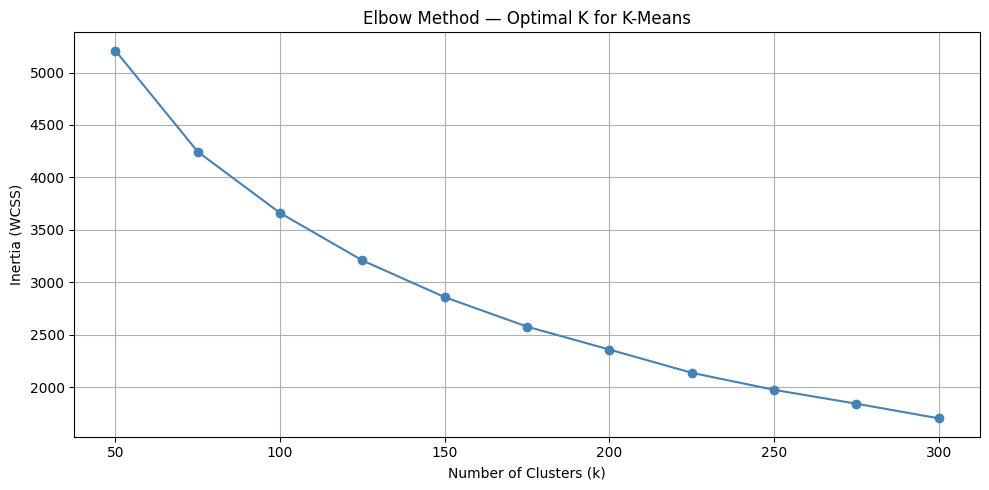

In [103]:
# Sample for speed; use full data for the final model
sample_idx = np.random.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)
X_sample   = X_scaled[sample_idx]

inertia_values = []
k_range = range(50, 301, 25)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertia_values.append(km.inertia_)
    print(f'  k={k:3d}  inertia={km.inertia_:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertia_values, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Optimal K for K-Means')
plt.grid(True)
plt.tight_layout()
plt.show()

### taking 75 as optimal cluster size here

In [104]:
NUM_CLUSTERS = 75

kmeans_model = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans_model.fit(X_scaled)

# Attach cluster labels to the clean dataframe
df_clean = df_scale_input.copy()
df_clean['Name']    = df_imp['Name'].values[:len(df_scale_input)]
df_clean['Cluster'] = kmeans_model.labels_

print(f'Training complete. Cluster label range: {df_clean["Cluster"].min()} – {df_clean["Cluster"].max()}')
print(f'Cluster sizes:\n{df_clean["Cluster"].value_counts().describe().to_string()}')

Training complete. Cluster label range: 0 – 74
Cluster sizes:
count     75.000000
mean     316.853333
std      134.791801
min      100.000000
25%      202.000000
50%      304.000000
75%      420.000000
max      632.000000


### KMeans Clustering Model Evaluaion

In [107]:
eval_idx   = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_eval     = X_scaled[eval_idx]
labels_eval= kmeans_model.labels_[eval_idx]

inertia   = kmeans_model.inertia_
sil_score = silhouette_score(X_eval, labels_eval, sample_size=2000, random_state=42)
ch_score  = calinski_harabasz_score(X_eval, labels_eval)
db_score  = davies_bouldin_score(X_eval, labels_eval)

print('─' * 45)
print(f'  Inertia (WCSS)               : {inertia:.2f}  lower is better, tighter clusters')
print(f'  Silhouette Score              : {sil_score:.4f}  closer to +1 is better, well seperated clusters')
print(f'  Calinski-Harabasz Score       : {ch_score:.2f}  higher is better, dense and well separated clusters')
print(f'  Davies-Bouldin Score          : {db_score:.4f}  lower is better, cluster less similar to each other')
print('─' * 45)

─────────────────────────────────────────────
  Inertia (WCSS)               : 34600.18  lower is better, tighter clusters
  Silhouette Score              : 0.2036  closer to +1 is better, well seperated clusters
  Calinski-Harabasz Score       : 301.45  higher is better, dense and well separated clusters
  Davies-Bouldin Score          : 1.3197  lower is better, cluster less similar to each other
─────────────────────────────────────────────


### save pickle file for future use

In [108]:
with open('kmeans_matchmaking_model.pkl', 'wb') as f:
    pickle.dump((kmeans_model, scaler, df_clean), f)

print("Model saved → 'kmeans_matchmaking_model.pkl'")
print(f'Bundle contents: KMeans ({NUM_CLUSTERS} clusters), StandardScaler, DataFrame ({len(df_clean)} rows)')

Model saved → 'kmeans_matchmaking_model.pkl'
Bundle contents: KMeans (75 clusters), StandardScaler, DataFrame (23764 rows)


### maintain a decoding map for readable match

In [109]:
DECODING_MAPS = {
    'status':      {0: 'single', 1: 'available', 2: 'seeing someone', 3: 'married', 4: 'unknown'},
    'sex':         {0: 'male',   1: 'female'},
    'orientation': {0: 'straight', 1: 'bisexual', 2: 'gay'},
    'drinks':      {0: 'not at all', 1: 'rarely', 2: 'socially', 3: 'often', 4: 'very often', 5: 'desperately'},
    'drugs':       {0: 'never', 1: 'sometimes', 2: 'often'},
    'smokes':      {0: 'no', 1: 'sometimes', 2: 'when drinking', 3: 'yes', 4: 'trying to quit'},
}
print('Decoding maps ready.')

Decoding maps ready.


### match making function for testing

In [110]:
def find_matches(user_dict, top_n_clusters=5, max_results=10):
    """
    Parameters
    ----------
    user_dict       : dict with keys matching CLUSTER_FEATURES and encoded integer values
    top_n_clusters  : how many nearest cluster centres to search
    max_results     : cap on number of returned matches (None = all)

    Returns
    -------
    pd.DataFrame of matches sorted by similarity score (ascending = most similar first)
    """
    with open('kmeans_matchmaking_model.pkl', 'rb') as f:
        km, sc, df_db = pickle.load(f)

    user_vec    = np.array([[user_dict[k] for k in CLUSTER_FEATURES]])
    user_scaled = sc.transform(user_vec)

    # Find N nearest cluster centres
    centre_dists = euclidean_distances(user_scaled, km.cluster_centers_).flatten()
    top_clusters = np.argsort(centre_dists)[:top_n_clusters]
    print(f'Searching clusters: {top_clusters.tolist()}')

    # Orientation-aware compatibility filter
    def compatible(row):
        uori, usex = user_dict['orientation'], user_dict['sex']
        csex, cori = row['sex'], row['orientation']
        if uori == 0:   # straight: wants opposite sex
            return (usex == 0 and csex == 1 and cori in [0, 1]) or                    (usex == 1 and csex == 0 and cori in [0, 1])
        elif uori == 1: # bisexual: open to any orientation
            return cori in [0, 1]
        elif uori == 2: # gay: same sex, also gay/bi
            return usex == csex and cori in [1, 2]
        return False

    nearby   = df_db[df_db['Cluster'].isin(top_clusters)].copy()
    cands    = nearby[nearby.apply(compatible, axis=1)].copy()
    print(f'Compatible candidates found: {len(cands)}')

    if cands.empty:
        print('No matches found.')
        return pd.DataFrame()

    cand_scaled = sc.transform(cands[CLUSTER_FEATURES])
    dists       = euclidean_distances(cand_scaled, user_scaled).flatten()
    cands       = cands.copy()
    cands['similarity_score'] = dists

    cands = cands.sort_values('similarity_score')
    if max_results:
        cands = cands.head(max_results)

    # Decode for display
    display = cands.copy()
    for col, mp in DECODING_MAPS.items():
        if col in display.columns:
            display[col] = display[col].map(mp)

    return display[['Name', 'age', 'sex', 'orientation', 'status',
                    'drinks', 'drugs', 'smokes', 'height', 'similarity_score']]

print('find_matches() function ready.')

find_matches() function ready.


### using a test case for inference

In [111]:
# ── Test 1: Straight male, 28 ──────────────────────────────────────────────
print('=' * 60)
print('TEST USER 1 — Straight male, age 28, social drinker, non-smoker')
print('=' * 60)
user1 = {
    'age': 28, 'status': 0, 'sex': 0, 'orientation': 0,
    'drinks': 2, 'drugs': 0, 'height': 70.0, 'smokes': 0
}
matches1 = find_matches(user1, top_n_clusters=5, max_results=10)
print(matches1.to_string(index=False))

TEST USER 1 — Straight male, age 28, social drinker, non-smoker
Searching clusters: [58, 6, 0, 43, 3]
Compatible candidates found: 3
   Name       age    sex orientation status     drinks drugs smokes   height  similarity_score
  Julie  1.906460 female    straight single   socially never     no 2.108521         72.761468
Chelsea -0.603007 female    straight single not at all never     no 1.384381         74.399787
Michael -0.182592 female    straight single not at all never     no 1.143048         74.462283


In [112]:
# ── Test 2: Straight female, 26, married ──────────────────────────────────
print('=' * 60)
print('TEST USER 2 — Straight female, age 26, social drinker, non-smoker')
print('=' * 60)
user2 = {
    'age': 26, 'status': 3, 'sex': 1, 'orientation': 0,
    'drinks': 2, 'drugs': 0, 'height': 61.0, 'smokes': 0
}
matches2 = find_matches(user2, top_n_clusters=5, max_results=10)
print(matches2.to_string(index=False))

TEST USER 2 — Straight female, age 26, social drinker, non-smoker
Searching clusters: [58, 6, 0, 43, 66]
Compatible candidates found: 1952
    Name      age  sex orientation status   drinks drugs smokes   height  similarity_score
 Herbert 1.538667 male    straight single socially never     no 2.832867         63.304463
    John 1.976225 male    straight single socially never     no 2.591396         63.359211
  Gerald 1.705559 male    straight single   rarely never     no 2.591396         63.472156
 William 1.479522 male    straight single socially never     no 2.591396         63.549207
 Michael 0.846799 male    straight single socially never     no 2.832867         63.575008
 Krystal 0.762706 male    straight single socially never     no 2.832867         63.608327
     Joe 1.290187 male    straight single socially never     no 2.591396         63.622501
Michelle 1.858338 male    straight single socially never     no 2.349948         63.626499
   Jason 1.152907 male    straight single 

In [113]:
# ── Test 3: Gay male, 28 ──────────────────────────────────────────────────
print('=' * 60)
print('TEST USER 3 — Gay male, age 28, non-drinker, occasional drug use')
print('=' * 60)
user3 = {
    'age': 28, 'status': 3, 'sex': 0, 'orientation': 2,
    'drinks': 0, 'drugs': 1, 'height': 72.0, 'smokes': 4
}
matches3 = find_matches(user3, top_n_clusters=5, max_results=10)
print(matches3.to_string(index=False))

TEST USER 3 — Gay male, age 28, non-drinker, occasional drug use
Searching clusters: [58, 6, 0, 43, 3]
Compatible candidates found: 413
   Name       age  sex orientation    status   drinks drugs    smokes   height  similarity_score
  David  1.080558 male         gay    single socially never        no 2.591396         74.726838
  Henry  0.927677 male         gay    single socially never        no 2.349948         75.006200
Shannon  1.906460 male    bisexual available   rarely never        no 1.867118         75.016104
Theresa -0.315174 male    bisexual    single socially never        no 2.832867         75.029936
Michael  0.062960 male         gay    single   rarely never        no 2.591396         75.074506
Melissa -0.056728 male         gay    single socially never        no 2.591396         75.144021
  Brian  1.005537 male         gay    single socially never        no 2.108521         75.202457
Randall -0.315174 male         gay    single socially never sometimes 2.591396         7